# AlexNet Implementation and Training from Scratch with CIFAR 10

## Imported Libraries

In [1]:
import os
import random
import numpy
import matplotlib.pyplot
import sklearn.model_selection
import sklearn.metrics

import torch
import torchvision
import collections

RNG Seed Setting

In [2]:
"""
-The seed provides a starting point for generating a series of random numbers.
-In relation to this AlexNet, the seed provides a starting point for selecting
 a series of filters and weights for the neural network for training. This
 eliminates the randomness of results produced by the training of the network.
-In essence, this allows others to reproduce your results exactly by utilizing
 the same seed.
"""

# set the overall seed here
rnd_seed = 2025

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

random.seed(rnd_seed)
numpy.random.seed(rnd_seed)

torch.manual_seed(rnd_seed)
torch.cuda.manual_seed(rnd_seed)
torch.cuda.manual_seed_all(rnd_seed)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

data_generator = torch.Generator().manual_seed(rnd_seed)

# if multiple python workers are eventually used...
def worker_init_fn(worker_id):
    random.seed(rnd_seed + worker_id)
    numpy.random.seed(rnd_seed + worker_id)

## On GPU balanced accuracy computation

In [3]:
def torch_compute_bacc(preds: torch.Tensor, labels: torch.Tensor, class_count: int):
    recall_per_class = []

    for label in range(class_count):
        true_positive = ((preds == label) & (labels == label)).sum().float()
        total_actual = (labels == label).sum().float()

        recall = true_positive / total_actual if total_actual > 0.0 else torch.tensor(0.0)
        recall_per_class.append(recall)

    return torch.stack(recall_per_class).mean().item()

## CIFAR 10 Download and Preparation

In [4]:
"""
-Class count: defines number of possible classes for each image to be classified.
-Batch size:  the number of images loaded into the GPU for training at a time.
-Image size:  a n x n pixel size of each input image.
-Validation split (val_split): from the original training partion of data, a decimal value
                               that takes a portion of the training partion to simulate a
                               test partion. Here, it is 0.2 so 20% of the training data
                               will be used to simulate testing. Basically like a quiz.
"""

# CIFAR-10 configuration
class_count = 10 # 10 classes in CIFAR 10
batch_size = 256
image_size = 224
val_split = 0.2

In [5]:
# dataset mean, stdev, and label weight computation
# transform each image to a uniform size (here, 224 x 224)
stat_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(image_size),
    torchvision.transforms.ToTensor(),
])

# download the training data
stat_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, \
                                                  transform=stat_transform)
stat_train_loader = torch.utils.data.DataLoader(stat_train_dataset, batch_size=batch_size, shuffle=True)

# after resizing the image, replace the RGB values with float values that can be graphed (normalization)
label_list, mean, std, count = [], 0.0, 0.0, 0.0
for images, labels in stat_train_loader:
    batch_count = images.size(0)
    images = images.view(batch_count, 3, -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    count += batch_count

    label_list.extend(labels.numpy())

# mean and std
mean /= count
std /= count

# label weight (inverse frequency)
label_count = collections.Counter(label_list)
label_total = sum(label_count.values())
label_weights = torch.tensor([label_total / (class_count * label_count[i]) for i in range(class_count)], \
                             dtype=torch.float)

"""
Mean and standard deviation of the input image RGB values are calculated as part
of the data normalization process. RBG has a domain of [0, 255] so it can only
represent positive numbers on a very limited range. To make training more applicable
to the real world, these RBG values are normalized to float (decimal) values so a wide
range of numbers can be represented. Computed from the TRAINING PARTITION ONLY.

-Label weights: some classes may have less samples than others, so to prevent
                bias towards the dominant class, assign more weight to classes
                with less samples and less weight to classes with more samples.
"""
print('Dataset Train Partition Stats')
print(f'        Mean: {mean}')
print(f'         Std: {std}')
print('Label Weights:', label_weights)

Files already downloaded and verified
Dataset Train Partition Stats
        Mean: tensor([0.4914, 0.4822, 0.4465])
         Std: tensor([0.1953, 0.1925, 0.1942])
Label Weights: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


In [6]:
# data loading
# train and test transforms/augmentations
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(image_size),
    torchvision.transforms.RandomCrop(image_size),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=mean, std=std)
])

""" Do not apply augmentations to testing """
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(image_size),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=mean, std=std)
])

# train vs. validation split, creates the "quiz partition"
train_val_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, \
                                                 transform=train_transform)
train_targets = train_val_dataset.targets
splitter = sklearn.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=val_split, random_state=rnd_seed)
train_idx, val_idx = next(splitter.split(numpy.zeros(len(train_targets)), train_targets))

train_dataset = torch.utils.data.Subset(train_val_dataset, train_idx)
val_dataset = torch.utils.data.Subset(train_val_dataset, val_idx)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# actual data loading for each partition, training, quiz, and test
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, \
                                           generator=data_generator)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, \
                                         generator=data_generator)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, \
                                          generator=data_generator)

Files already downloaded and verified
Files already downloaded and verified


## AlexNet Implementation

In [7]:
"""
Implementation based on: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

See Figure 2
"""

class AlexNet(torch.nn.Module):
    def __init__(self, class_count):
        super(AlexNet, self).__init__()

        # Hidden convolution layers
        self.layer1 = torch.nn.Sequential(
            # In the beginning, there are only three channels as the input
            # is represented in RGB values
            torch.nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            torch.nn.ReLU(inplace=True),
            torch.nn.MaxPool2d(kernel_size=3, stride=2)
        ) # output: (96, 55, 55)

        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(96, 256, kernel_size=5, padding=2),
            torch.nn.ReLU(inplace=True),
            torch.nn.MaxPool2d(kernel_size=3, stride=2),
        ) # output: (256, 27, 27)

        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(256, 384, kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
        ) # output: (384, 13, 13)

        self.layer4 = torch.nn.Sequential(
            torch.nn.Conv2d(384, 384, kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
        ) # output: (384, 13, 13)

        self.layer5 = torch.nn.Sequential(
            torch.nn.Conv2d(384, 256, kernel_size=3, padding=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.MaxPool2d(kernel_size=3, stride=2)
        ) # output: (256, 13, 13)

        # Fully connected "head" layer
        self.head = torch.nn.Sequential(
            torch.nn.Dropout(0.5),
            torch.nn.Linear(256 * 6 * 6, 4096),
            torch.nn.ReLU(inplace=True),

            torch.nn.Dropout(0.5),
            torch.nn.Linear(4096, 4096),
            torch.nn.ReLU(inplace=True),
        )

        self.last = torch.nn.Linear(4096, class_count)

    def forward(self, x):
        # Pass image through layers 1-5
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        # Transforms the input image into a vector-like object
        # makes it easier for the neural network to process because
        # there are no more convolutions occuring.
        x = torch.flatten(x, 1)  # flatten all but batch dimension
        # Pass the image through the fully connected layers
        x = self.head(x)
        x = self.last(x)
        return x

## Network Training

In [8]:
# training configuration
gpu="0" # change as required for your GPU

"""
-Learning rate (lr) - Given the need to minimize the loss, gradient descent enables
                      enables us to find only the direction of minimization, but not
                      how much we should move toward that direction, which is where lr comes
                      into play (start large, decrease with time).
-Momentum           - Insists on the use of moving toward a single direction, the value represents
                      the insistance (0 < m < 1), the closer to 1, the stronger the insistance.
-Weight decay       - Regularization factor, limits the ability to adjust connection weights
                      during backpropagation with each step. Avoids overfitting.
-Max epochs         - Maximum amount of times backpropagation is conducted.
-Patience           - Determines when to stop learning on a certain models after n failed attempts and
                      revert to the most successful model.
"""

# AlexNet used these parameters to train
lr = 0.01
momentum = 0.9
w_decay=0.0005

max_epochs = 100
patience = 10

In [9]:
# training preparation
device = torch.device("cuda:" + gpu if torch.cuda.is_available() else "cpu")
model = AlexNet(class_count=class_count).to(device)
label_weights = label_weights.to(device)
# Computes the loss with every step
criterion = torch.nn.CrossEntropyLoss(weight=label_weights)
# Mini batch stochastic gradient descent
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=w_decay)

# training stop control
best_bacc = float('-inf')
# Reduce patience count with every failure
patience_count = patience

# training loop
for epoch in range(max_epochs):
    # train
    model.train()
    train_loss, train_preds, train_labels = 0.0, [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Once loss computed, start backpropagation process
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)

        train_preds.append(predicted)
        train_labels.append(labels)

    train_preds = torch.cat(train_preds)
    train_labels = torch.cat(train_labels)

    # Compute balanced accuracy, recalculate loss
    train_bacc = torch_compute_bacc(train_preds, train_labels, class_count)
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss, val_preds, val_labels = 0.0, [], []

    with torch.no_grad():
        # Same training process as training partition, but without backpropagation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            val_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)

            val_preds.append(predicted)
            val_labels.append(labels)

    val_preds = torch.cat(val_preds)
    val_labels = torch.cat(val_labels)

    val_bacc = torch_compute_bacc(val_preds, val_labels, class_count)
    val_loss /= len(val_loader)

    print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train BAcc={train_bacc * 100.0:.2f}%, \
          Val Loss={val_loss:.4f}, Val BAcc={val_bacc * 100.0:.2f}%, Patience={patience_count}")

    # check patience, early stop if balanced accuracy gets worse
    if val_bacc > best_bacc:
        best_bacc = val_bacc
        torch.save(model.state_dict(), "alexnet_cifar10_model.pth")
        patience_count = patience
    else:
        patience_count -= 1
        if patience_count <= 0:
            print(f"Balanced accuracy got worse for {patience} consecutive times; stopping early.")
            break

Epoch 1: Train Loss=2.2075, Train BAcc=16.02%,           Val Loss=1.9526, Val BAcc=27.70%, Patience=10
Epoch 2: Train Loss=1.7425, Train BAcc=36.27%,           Val Loss=1.5965, Val BAcc=42.24%, Patience=10
Epoch 3: Train Loss=1.4530, Train BAcc=46.67%,           Val Loss=1.5175, Val BAcc=46.76%, Patience=10
Epoch 4: Train Loss=1.3094, Train BAcc=52.53%,           Val Loss=1.2455, Val BAcc=56.24%, Patience=10
Epoch 5: Train Loss=1.1446, Train BAcc=59.21%,           Val Loss=1.1696, Val BAcc=59.39%, Patience=10
Epoch 6: Train Loss=1.0051, Train BAcc=64.68%,           Val Loss=1.0473, Val BAcc=64.26%, Patience=10
Epoch 7: Train Loss=0.8908, Train BAcc=68.94%,           Val Loss=0.8676, Val BAcc=70.50%, Patience=10
Epoch 8: Train Loss=0.7997, Train BAcc=72.61%,           Val Loss=0.8598, Val BAcc=71.71%, Patience=10
Epoch 9: Train Loss=0.7241, Train BAcc=74.96%,           Val Loss=0.7360, Val BAcc=75.25%, Patience=10
Epoch 10: Train Loss=0.6775, Train BAcc=76.51%,           Val Loss=0.6223

Epoch 81: Train Loss=0.0342, Train BAcc=98.87%,           Val Loss=0.5898, Val BAcc=86.33%, Patience=7
Epoch 82: Train Loss=0.0261, Train BAcc=99.20%,           Val Loss=0.5798, Val BAcc=87.58%, Patience=6
Epoch 83: Train Loss=0.0290, Train BAcc=99.06%,           Val Loss=0.6249, Val BAcc=86.26%, Patience=10
Epoch 84: Train Loss=0.0260, Train BAcc=99.22%,           Val Loss=0.5682, Val BAcc=87.44%, Patience=9
Epoch 85: Train Loss=0.0304, Train BAcc=98.92%,           Val Loss=0.5693, Val BAcc=87.32%, Patience=8
Epoch 86: Train Loss=0.0255, Train BAcc=99.16%,           Val Loss=0.5983, Val BAcc=86.97%, Patience=7
Epoch 87: Train Loss=0.0264, Train BAcc=99.13%,           Val Loss=0.5714, Val BAcc=87.57%, Patience=6
Epoch 88: Train Loss=0.0287, Train BAcc=99.10%,           Val Loss=0.5506, Val BAcc=87.32%, Patience=5
Epoch 89: Train Loss=0.0284, Train BAcc=99.06%,           Val Loss=0.5646, Val BAcc=87.28%, Patience=4
Epoch 90: Train Loss=0.0250, Train BAcc=99.19%,           Val Loss=0.583

## Network Evaluation

In [10]:
# loads the saved model
model.load_state_dict(torch.load('alexnet_cifar10_model.pth'))

# evaluates on the test partition
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        test_preds.append(predicted)
        test_labels.append(labels)

test_preds = torch.cat(test_preds)
test_labels = torch.cat(test_labels)

test_bacc = torch_compute_bacc(test_preds, test_labels, class_count)
print(f"Test Balanced Accuracy: {test_bacc * 100.0:.2f}%")

Test Balanced Accuracy: 87.19%


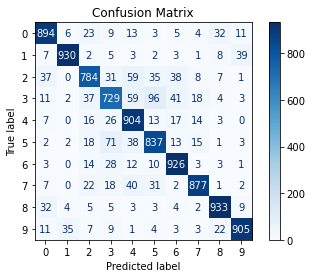

In [11]:
# confusion matrix
cm = sklearn.metrics.confusion_matrix(test_labels.cpu(), test_preds.cpu())
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
matplotlib.pyplot.title("Confusion Matrix")
matplotlib.pyplot.show()